<a href="https://colab.research.google.com/github/Karthik5412/wardrobe_cnn/blob/main/dl_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive

drive.mount('/content/drive/')


Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [2]:
import zipfile
from pathlib import Path
extract_path = Path("/content/extracted_data")

with zipfile.ZipFile('/content/drive/MyDrive/Deep_Learning/custumes/archive (23).zip', 'r') as ref:
    ref.extractall('extracted_data')

In [17]:
from tensorflow.keras.utils import image_dataset_from_directory
selected_classes = ['shirt', 'pants', 'shoes']

train_ds = image_dataset_from_directory('/content/extracted_data/clothing-dataset-small/train',labels='inferred',label_mode='int', color_mode='rgb', seed=123,image_size=(224,224), batch_size=32, class_names=selected_classes)

test_ds = image_dataset_from_directory('/content/extracted_data/clothing-dataset-small/test',labels='inferred',label_mode='int', color_mode='rgb', seed=123,image_size=(224,224), batch_size=32,class_names=selected_classes)

Found 956 files belonging to 3 classes.
Found 141 files belonging to 3 classes.


In [18]:
train_ds.class_names

['shirt', 'pants', 'shoes']

In [19]:
import pandas as pd
import numpy as np

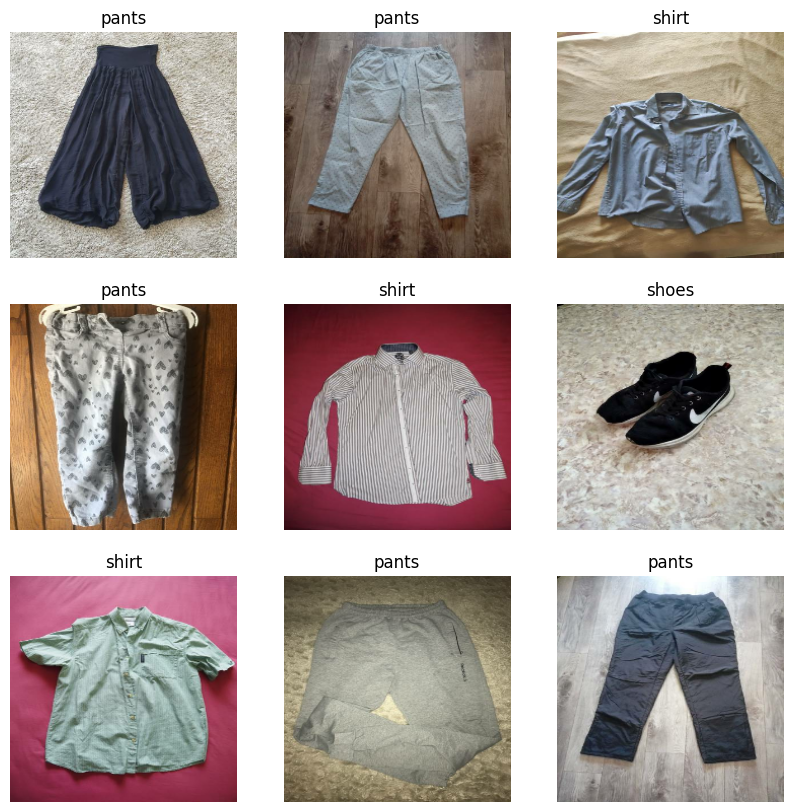

In [20]:
import matplotlib.pyplot as plt

class_names = train_ds.class_names
plt.figure(figsize=(10,10))

for img,label in train_ds.take(1):
    for i in range(0,9):
        plt.subplot(3,3,i+1)

        plt.imshow(img[i].numpy().astype('uint8'))
        plt.title(class_names[label[i]])
        plt.axis('off')





In [21]:
from tensorflow.keras import layers
from tensorflow.keras import Sequential

aug = Sequential([
    layers.RandomRotation(0.05, input_shape=(224,224,3),fill_mode='nearest'),
    layers.RandomFlip('horizontal'),
    layers.RandomZoom(0.1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


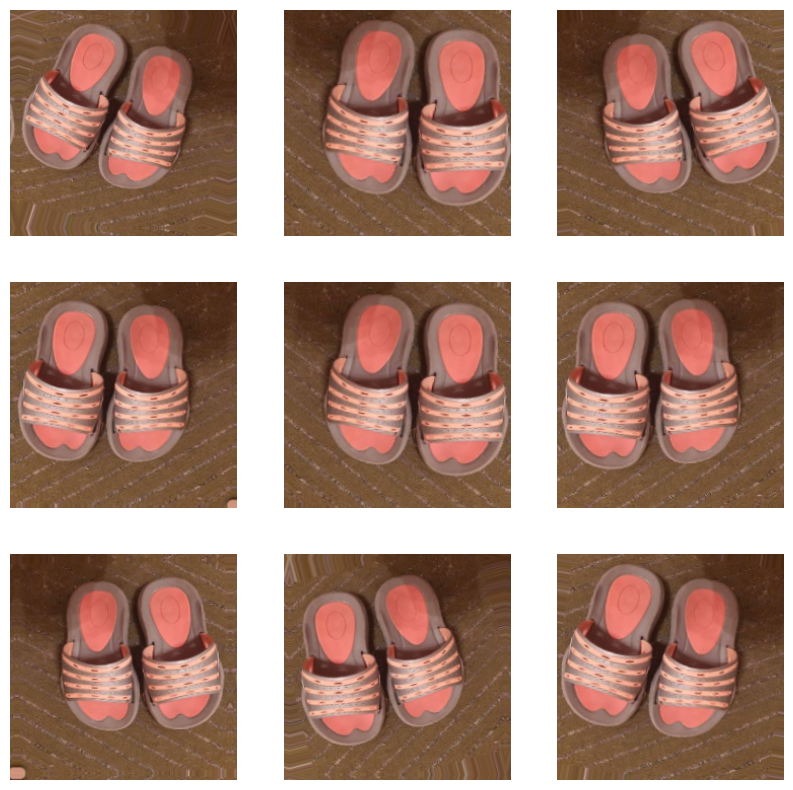

In [22]:
import tensorflow as tf
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))

for img,labels in train_ds.take(1):

    for i in range(9):
        agumented = aug(img)
        plt.subplot(3,3,i+1)
        plt.imshow(agumented[12].numpy().astype('uint8'))
        plt.axis('off')

In [23]:
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras.applications.resnet50 import preprocess_input

base_model = ResNet50V2(
    input_shape=(224,224,3),
    include_top = False,
    weights='imagenet')

base_model.trainable=False

In [24]:
from tensorflow.keras.layers import Conv2D, MaxPool2D, GlobalAveragePooling2D, Dense, Dropout, Flatten, Lambda, Rescaling
from tensorflow.keras import Sequential

In [41]:
cnn = Sequential([
    aug,
    Rescaling(scale=2.0/255.0, offset=-1.0),
    # Lambda(lambda x: preprocess_input(x)),
    base_model,
    GlobalAveragePooling2D(),
    Dense(256,activation='relu'),
    Dropout(0.3),
    Dense(128,activation='relu'),
    Dropout(0.2),
    Dense(3,activation='softmax'),
])

In [42]:
from tensorflow.keras.optimizers import Adam
ado = Adam(learning_rate=0.002)
closet_loss_function = tf.keras.losses.SparseCategoricalCrossentropy(
    from_logits=False,
    name='sparse_categorical_crossentropy'
)


cnn.compile(optimizer=ado,loss=closet_loss_function,metrics=['accuracy'])

In [43]:
cnn.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50v2 (Functional)         │ (None, 7, 7, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,122,627 (92.02 MB)

 Trainable params: 557,827 (2.13 MB)

 Non-trainable params: 23,564,800 (89.89 MB)

In [44]:
cnn.fit(train_ds,epochs=25,verbose=1,validation_data=test_ds)

Epoch 1/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 13s 193ms/step - accuracy: 0.9027 - loss: 0.2428 - val_accuracy: 1.0000 - val_loss: 3.3135e-04
Epoch 2/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 136ms/step - accuracy: 0.9854 - loss: 0.0405 - val_accuracy: 1.0000 - val_loss: 0.0015
Epoch 3/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 139ms/step - accuracy: 0.9833 - loss: 0.0390 - val_accuracy: 0.9929 - val_loss: 0.0094
Epoch 4/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 133ms/step - accuracy: 0.9916 - loss: 0.0166 - val_accuracy: 0.9929 - val_loss: 0.0078
Epoch 5/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 135ms/step - accuracy: 0.9916 - loss: 0.0363 - val_accuracy: 1.0000 - val_loss: 0.0048
Epoch 6/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 146ms/step - accuracy: 0.9958 - loss: 0.0116 - val_accuracy: 1.0000 - val_loss: 2.3796e-04
Epoch 7/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 136ms/step - accuracy: 0.9948 - loss: 0.0154 - val_accuracy: 1.0000 - val_loss: 1.2973e-05
Epoch 8/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 136ms/step - accuracy: 0.9948 - loss: 0.0242 - val

In [45]:
cnn.save('cnn_linear.keras')